<a href="https://colab.research.google.com/github/jonathangtz27/chessstuffNew/blob/main/chess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [11]:
file_path = "positions.csv"
data = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "nikitricky/chess-positions",
  file_path
)
# bot is now given all the info
print("First 5 records:")
print(data.head())
print(f"\nDataset size: {len(data)} positions")
print("\nAll column names:")
print(data.columns.tolist())
print("\nMissing values per column:")
print(data.isnull().sum())

Using Colab cache for faster access to the 'chess-positions' dataset.


/usr/local/lib/python3.12/dist-packages/kagglehub/pandas_datasets.py:92: DtypeWarning: Columns (12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


First 5 records:
                                                 fen playing  score  mate  \
0  rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...    e2e4  -35.0   NaN   
1  rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...    e7e6   36.0   NaN   
2  rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBN...    d2d4  -27.0   NaN   
3  rnbqkbnr/p1pp1ppp/1p2p3/8/3PP3/8/PPP2PPP/RNBQK...    b7b6   81.0   NaN   
4  rnbqkbnr/p1pp1ppp/1p2p3/8/3PP3/P7/1PP2PPP/RNBQ...    a2a3  -65.0   NaN   

   depth   game_id        date      time  white    black white_result  \
0     20  j1dkb5dw  2012.12.31  23:01:03  BFG9k  mamalak            1   
1     22  j1dkb5dw  2012.12.31  23:01:03  BFG9k  mamalak            1   
2     24  j1dkb5dw  2012.12.31  23:01:03  BFG9k  mamalak            1   
3     20  j1dkb5dw  2012.12.31  23:01:03  BFG9k  mamalak            1   
4     22  j1dkb5dw  2012.12.31  23:01:03  BFG9k  mamalak            1   

  black_result white_elo black_elo                           opening  \
0        

In [12]:
print("\nColumn names and types:")
print(data.dtypes)


print("POSITION DATA SUMMARY")

print(f"\nTotal positions: {len(data):,}")
print(f"Positions with score (centipawns): {data['score'].notna().sum():,}")
print(f"Positions with mate evaluation: {data['mate'].notna().sum():,}")

print("\nScore Distribution (non-mate positions)")
print(data['score'].describe())

print("\nMate Distribution")
print(data['mate'].describe())

print("\n--- Who's to Move ---")
print(data['playing'].value_counts())


Column names and types:
fen              object
playing          object
score           float64
mate            float64
depth             int64
game_id          object
date             object
time             object
white            object
black            object
white_result     object
black_result     object
white_elo        object
black_elo        object
opening          object
time_control     object
termination      object
dtype: object
POSITION DATA SUMMARY

Total positions: 1,091,078
Positions with score (centipawns): 981,566
Positions with mate evaluation: 109,512

Score Distribution (non-mate positions)
count    981566.000000
mean         20.746932
std         651.694704
min      -20000.000000
25%        -129.000000
50%           7.000000
75%         197.000000
max       20000.000000
Name: score, dtype: float64

Mate Distribution
count    109512.000000
mean          0.587881
std           9.072899
min         -71.000000
25%          -5.000000
50%           1.000000
75%       

In [13]:
# Explore all numeric columns
numeric_cols = data.select_dtypes(include=[np.number]).columns
print("\nNumeric columns available:")
for col in numeric_cols:
    print(f"\n{col}:")
    print(data[col].describe())


Numeric columns available:

score:
count    981566.000000
mean         20.746932
std         651.694704
min      -20000.000000
25%        -129.000000
50%           7.000000
75%         197.000000
max       20000.000000
Name: score, dtype: float64

mate:
count    109512.000000
mean          0.587881
std           9.072899
min         -71.000000
25%          -5.000000
50%           1.000000
75%           6.000000
max          70.000000
Name: mate, dtype: float64

depth:
count    1.091078e+06
mean     3.327937e+01
std      4.161055e+01
min      0.000000e+00
25%      2.200000e+01
50%      2.300000e+01
75%      2.500000e+01
max      2.450000e+02
Name: depth, dtype: float64


In [14]:
def create_evaluation(row):

   ## Combine score and mate into single evaluation.
   ## Mate positions get extreme values to indicate forced win/loss.

    if pd.notna(row['mate']):
        # Positive mate = white is mating, negative = black is mating
        # Use large values to indicate mate
        if row['mate'] > 0:
            return 10000 - row['mate'] * 10  #closer mates = higher value
        else:
            return -10000 - row['mate'] * 10
    else:
        # Regular centipawn score
        return row['score']

data['evaluation'] = data.apply(create_evaluation, axis=1)

print("\nEvaluation distribution:")
print(data['evaluation'].describe())


Evaluation distribution:
count    1.091078e+06
mean     9.128649e+01
std      3.205311e+03
min     -2.000000e+04
25%     -1.750000e+02
50%      8.000000e+00
75%      2.710000e+02
max      2.000000e+04
Name: evaluation, dtype: float64


In [15]:
def fen_to_features_enhanced(row):
    """
    Convert FEN string to features AND include ELO and other metadata
    """
    fen = row['fen']

    # Split FEN into components
    parts = fen.split()
    board = parts[0]
    turn = parts[1] if len(parts) > 1 else 'w'
    castling = parts[2] if len(parts) > 2 else '-'

    # Basic piece values
    piece_values = {
        'P': 1, 'N': 3, 'B': 3, 'R': 5, 'Q': 9, 'K': 0,
        'p': -1, 'n': -3, 'b': -3, 'r': -5, 'q': -9, 'k': 0
    }

    # Count material
    material_balance = sum(piece_values.get(char, 0) for char in board)

    # Count each piece type
    white_pawns = board.count('P')
    black_pawns = board.count('p')
    white_knights = board.count('N')
    black_knights = board.count('n')
    white_bishops = board.count('B')
    black_bishops = board.count('b')
    white_rooks = board.count('R')
    black_rooks = board.count('r')
    white_queens = board.count('Q')
    black_queens = board.count('q')

    # Turn value
    turn_value = 1 if turn == 'w' else -1

    # Castling rights
    can_castle_white_kingside = 1 if 'K' in castling else 0
    can_castle_white_queenside = 1 if 'Q' in castling else 0
    can_castle_black_kingside = 1 if 'k' in castling else 0
    can_castle_black_queenside = 1 if 'q' in castling else 0

    # Build feature list - board features first
    features = [
        material_balance,
        white_pawns, black_pawns,
        white_knights, black_knights,
        white_bishops, black_bishops,
        white_rooks, black_rooks,
        white_queens, black_queens,
        turn_value,
        can_castle_white_kingside, can_castle_white_queenside,
        can_castle_black_kingside, can_castle_black_queenside
    ]

    # Add ALL other numeric columns from the dataset (like ELO, etc.)
    for col in data.columns:
        if col not in ['fen', 'playing', 'score', 'mate', 'evaluation'] and pd.api.types.is_numeric_dtype(data[col]):
            # Handle missing values - fill with median
            value = row[col] if pd.notna(row[col]) else data[col].median()
            features.append(value)

    return features

In [16]:
print("Converting positions to features")
X = np.array([fen_to_features_enhanced(row) for _, row in data.iterrows()])
y = data['evaluation'].values

# See what extra features we're using
extra_numeric_cols = [col for col in data.columns
                      if col not in ['fen', 'playing', 'score', 'mate', 'evaluation']
                      and pd.api.types.is_numeric_dtype(data[col])]
print(f"\nExtra numeric features added: {extra_numeric_cols}")
print(f"Total features: {X.shape[1]}")

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("Conversion complete!")

Converting positions to features

Extra numeric features added: ['depth']
Total features: 17

Feature matrix shape: (1091078, 17)
Target shape: (1091078,)
Conversion complete!


In [17]:

#split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]:,}")
print(f"Test set size: {X_test.shape[0]:,}")

##------------------------------------------------Normalization-------------------------------------##
# Normalize features (X)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Normalize target variable (y)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

print("\n✓ Features normalized using StandardScaler")
print("✓ Target variable normalized using StandardScaler")
print(f"\nScaled features - mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}")
print(f"Scaled target - mean: {y_train_scaled.mean():.6f}, std: {y_train_scaled.std():.6f}")
##--------------------------------------------------------------------------------------------------##
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train_scaled)
print("Linear Regression training complete")

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=100,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_model.fit(X_train_scaled, y_train_scaled)
print(" Random Forest training complete")

Training set size: 872,862
Test set size: 218,216

✓ Features normalized using StandardScaler
✓ Target variable normalized using StandardScaler

Scaled features - mean: 0.000000, std: 1.000000
Scaled target - mean: -0.000000, std: 1.000000
Linear Regression training complete


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  3.8min


 Random Forest training complete


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  7.8min finished


In [18]:
# Make predictions on normalized scale
y_pred_linear_scaled = linear_model.predict(X_test_scaled)
y_pred_rf_scaled = rf_model.predict(X_test_scaled)

# Convert predictions back to original scale for interpretability
y_pred_linear = scaler_y.inverse_transform(y_pred_linear_scaled.reshape(-1, 1)).ravel()
y_pred_rf = scaler_y.inverse_transform(y_pred_rf_scaled.reshape(-1, 1)).ravel()

#metrics for LR
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

#metrics for RF
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

#linear vs forest
print("MODEL COMPARISON")
print("")
print(f"{'Metric':<30} {'Linear Regression':<20} {'Random Forest':<20}")
print("")
print(f"{'MAE (centipawns)':<30} {mae_linear:<20.2f} {mae_rf:<20.2f}")
print(f"{'RMSE (centipawns)':<30} {rmse_linear:<20.2f} {rmse_rf:<20.2f}")
print(f"{'R² Score':<30} {r2_linear:<20.3f} {r2_rf:<20.3f}")



[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    1.2s


MODEL COMPARISON

Metric                         Linear Regression    Random Forest       

MAE (centipawns)               1276.40              402.74              
RMSE (centipawns)              3157.55              1379.25             
R² Score                       0.022                0.813               


[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    2.9s finished


In [19]:
import matplotlib.pyplot as plt

# Get feature importances from the Random Forest model
importances = rf_model.feature_importances_

# get the features from the piece count
feature_names = [
    'material_balance',
    'white_pawns', 'black_pawns',
    'white_knights', 'black_knights',
    'white_bishops', 'black_bishops',
    'white_rooks', 'black_rooks',
    'white_queens', 'black_queens',
    'turn_value',
    'castle_white_K', 'castle_white_Q',
    'castle_black_k', 'castle_black_q'
]

# add the rest of the features
extra_numeric_cols = [col for col in data.columns
                      if col not in ['fen', 'playing', 'score', 'mate', 'evaluation']
                      and pd.api.types.is_numeric_dtype(data[col])]
feature_names.extend(extra_numeric_cols)

# Create a sorted list of tuples
feature_importance_pairs = list(zip(feature_names, importances))
feature_importance_pairs.sort(key=lambda x: x[1], reverse=True)

# Print top 10 most important features
print("TOP 10 MOST IMPORTANT FEATURES")
print("="*60)
for i, (name, importance) in enumerate(feature_importance_pairs[:10], 1):
    print(f"{i:2d}. {name:<30s} {importance:.4f}")
print("="*60)

TOP 10 MOST IMPORTANT FEATURES
 1. material_balance               0.7081
 2. turn_value                     0.1312
 3. depth                          0.1015
 4. white_pawns                    0.0094
 5. black_pawns                    0.0085
 6. black_rooks                    0.0076
 7. white_rooks                    0.0065
 8. white_queens                   0.0051
 9. black_queens                   0.0047
10. black_bishops                  0.0046


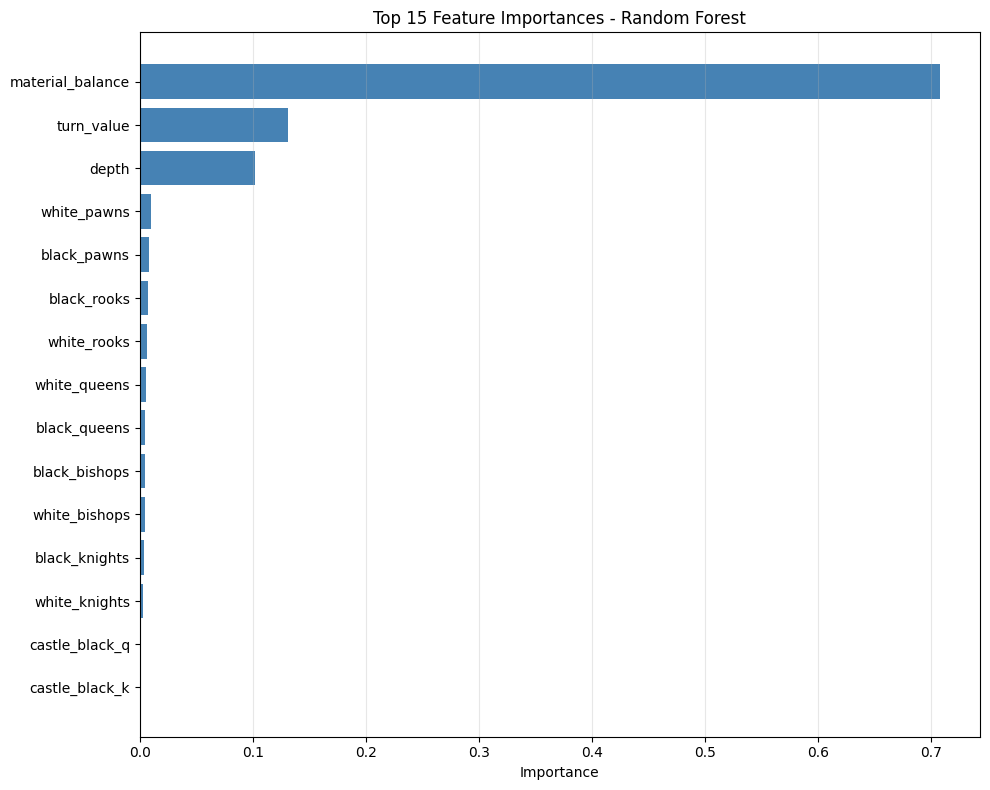


Showing top 15 features out of 17 total features


In [20]:
# Create bar plot of feature importances
fig, ax = plt.subplots(figsize=(10, 8))

# Get top 15 features for cleaner visualization
top_n = 15
top_features = feature_importance_pairs[:top_n]
top_names = [name for name, _ in top_features]
top_importances = [imp for _, imp in top_features]

# Create horizontal bar plot
y_pos = np.arange(len(top_names))
ax.barh(y_pos, top_importances, align='center', color='steelblue')
ax.set_yticks(y_pos)
ax.set_yticklabels(top_names)
ax.invert_yaxis()  # Highest importance at top
ax.set_xlabel('Importance')
ax.set_title(f'Top {top_n} Feature Importances - Random Forest')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nShowing top {top_n} features out of {len(feature_names)} total features")

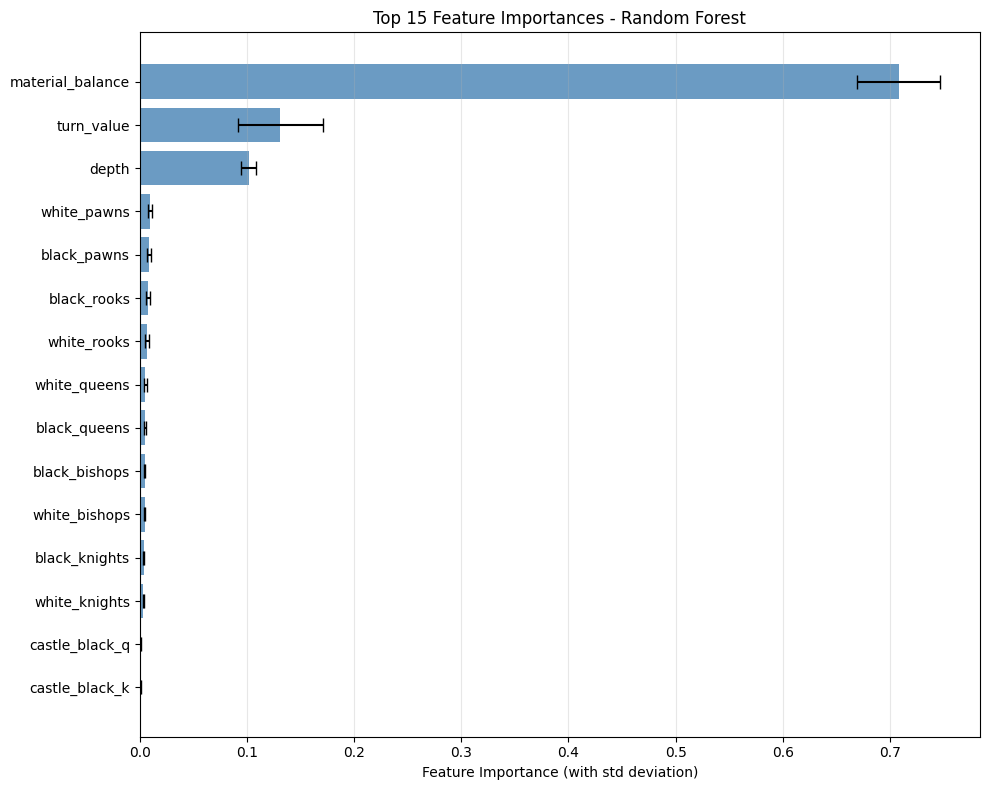

In [21]:
# Calculate standard deviation of importances across all trees
std = np.std([tree.feature_importances_ for tree in rf_model.estimators_], axis=0)

# Create bar plot with error bars
fig, ax = plt.subplots(figsize=(10, 8))

top_n = 15
top_indices = np.argsort(importances)[::-1][:top_n]
top_names = [feature_names[i] for i in top_indices]
top_importances = importances[top_indices]
top_std = std[top_indices]

y_pos = np.arange(len(top_names))
ax.barh(y_pos, top_importances, xerr=top_std, align='center',
        color='steelblue', alpha=0.8, ecolor='black', capsize=5)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_names)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (with std deviation)')
ax.set_title(f'Top {top_n} Feature Importances - Random Forest')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()